# Image Segmentation
In this notebook, we'll examine a new application for Convolutional Neural Networks (CNNs) - image segmentation. This notebook will build on the classification example shown in the previous notebooks using CNNs.

**Learning Objectives**

1. Describe the U-net architecture for CNNs.
2. Implement a U-net in PyTorch for image segmentation.
3. Test various modifications for a U-net to improve the segmentation.

**Import modules**

Begin by importing the modules to be used in this notebook.

In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.gridspec as gridspec
import numpy as np
import scipy
from IPython.display import Image as IPI
from IPython.display import display

In [2]:
# packages for PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader, random_split

Let's prepare our device to use PyTorch:

In [3]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Using device:", device)

Using device: mps


Finally, let's set up some paths:

In [4]:
data_dir = os.path.join('..','data','gametophyte_images')
images_dir = os.path.join('..','images')

## Motivation
In our previous examples with CNNs, we built a convolutional neural network for image classification. In other words, each image produced a single output value (class label). Here, we are going to explore how we can classify *each pixel* in an image.

In the example for this notebook, we are going to consider some data from MLML graduate student Natalie Colao studying the effects of light on the growth of bull kelp gametophytes. This microscopic life stage of bull kelp develops from spores that settle on the sea floor. When conditions are favorable for reproduction, the male gametophytes fertilize female gametophytes, leading to the growth of sporophytes. The following image shows the role of gametophytes in the bull kelp lifecycle:

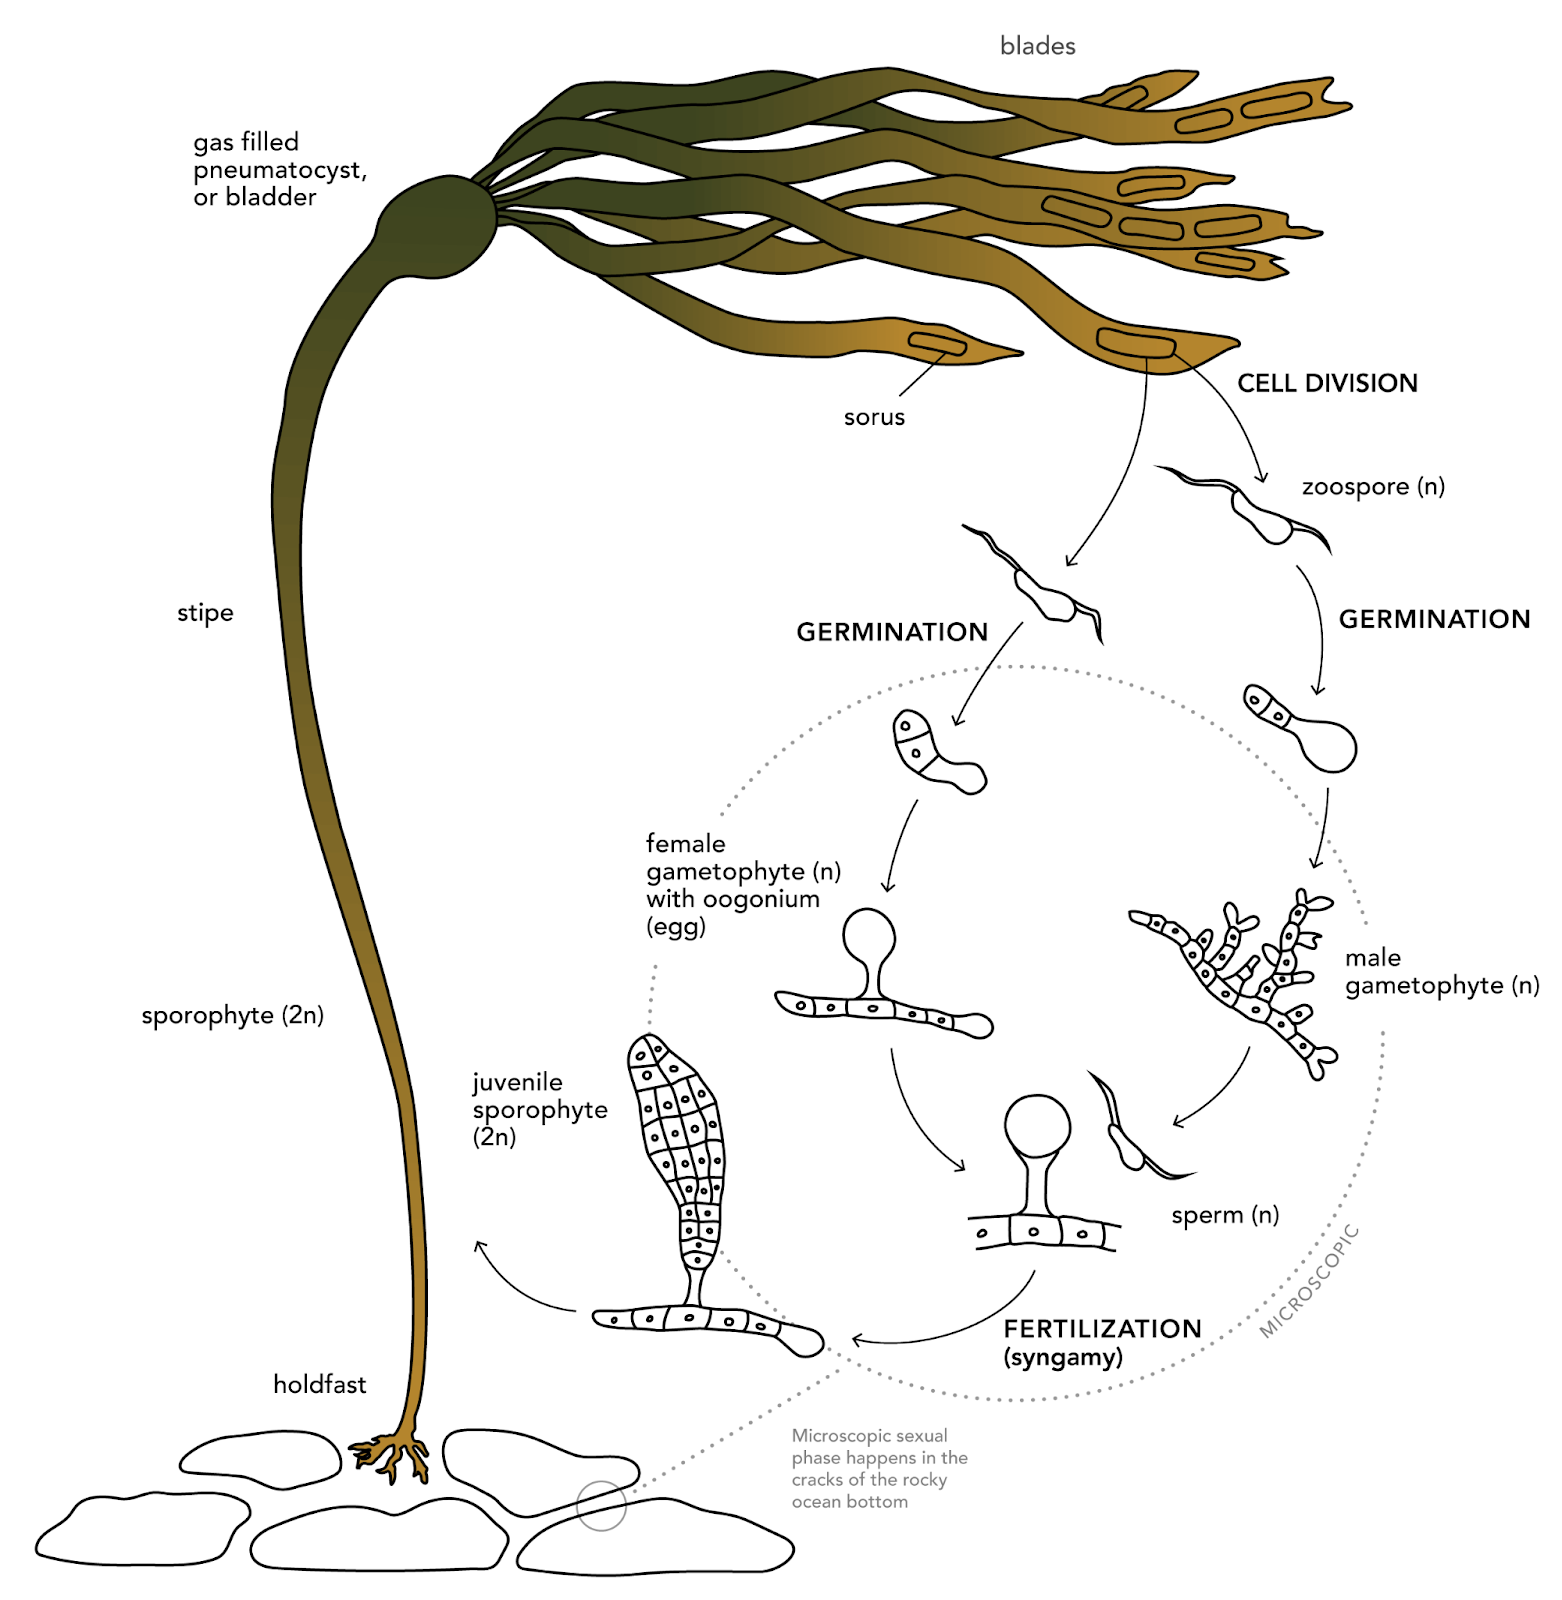

In [5]:
display(IPI(filename=os.path.join(images_dir, 'bull_kelp_lifecycle.png'), width=500))

Image Credit: [bullkelp.info](https://bullkelp.info/characters/bull-kelp)

In this notebook, we are going to take on the task of classifying pixels in microscope imagery to determine whether or not they represent gametophytes. This is an important task when analyzing microscope imagery because the slides will often have lots of small features that may appear similar to the features of interest.

Let's have a peek at some example images from Natalie's experiment:

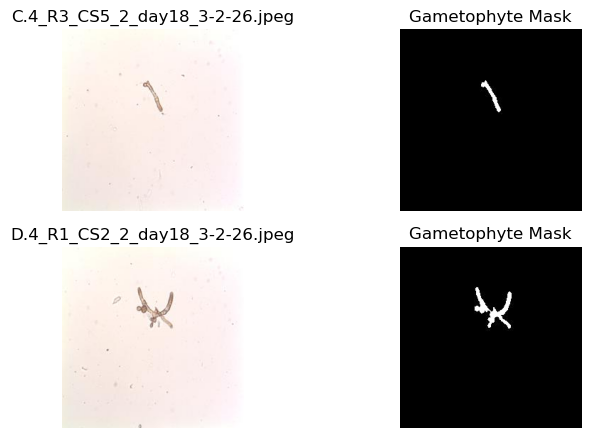

In [6]:
# get the paths of the images
img_names = ['C.4_R3_CS5_2_day18_3-2-26.jpeg',
             'D.4_R1_CS2_2_day18_3-2-26.jpeg']

fig = plt.figure(figsize=(8,8))

for i, img_name in enumerate(img_names):

    img_path = os.path.join(data_dir, 'Images', img_name)
    msk_path = os.path.join(data_dir, 'Masks', img_name[:-5]+'_mask.jpg')

    img = Image.open(img_path).convert("RGB")
    msk = Image.open(msk_path).convert("L")

    plt.subplot(3,2,i*2+1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')

    plt.subplot(3,2,i*2+2)
    C = plt.imshow(np.array(msk)/255,vmin=0,vmax=1,cmap='Grays_r')
    plt.title('Gametophyte Mask')
    plt.axis('off')

plt.show()

As we can see, the gametophytes are visible in the microscope images in addition to lots of other smaller features that are not gametophytes. The corresponding masks identify whether the pixel in the image is a gametophyte (1) or not (0). These masks were created by hand with image processing software - a time-intensive endeavor. Here, we will build a model to take in the microscope images and return the associated mask for analysis so that they can be automatically generated for new imagery.

## The U-net Architecture

The U-net architecture is a type of convolutional neural network that is designed for image segmentation tasks. The start of the network is similar to the neural network we investigated previously for image classification tasks. In that network, a series of convolutional and pooling layers reduced the width and height of the images. These layers are what we might call *down-sampling* or *encoding*. In a U-net architecture, this process is reversed and there is an *up-sampling* or *decoding* layer that recovers the image dimensions. In this example, we will take a look at a U-net with the following structure:

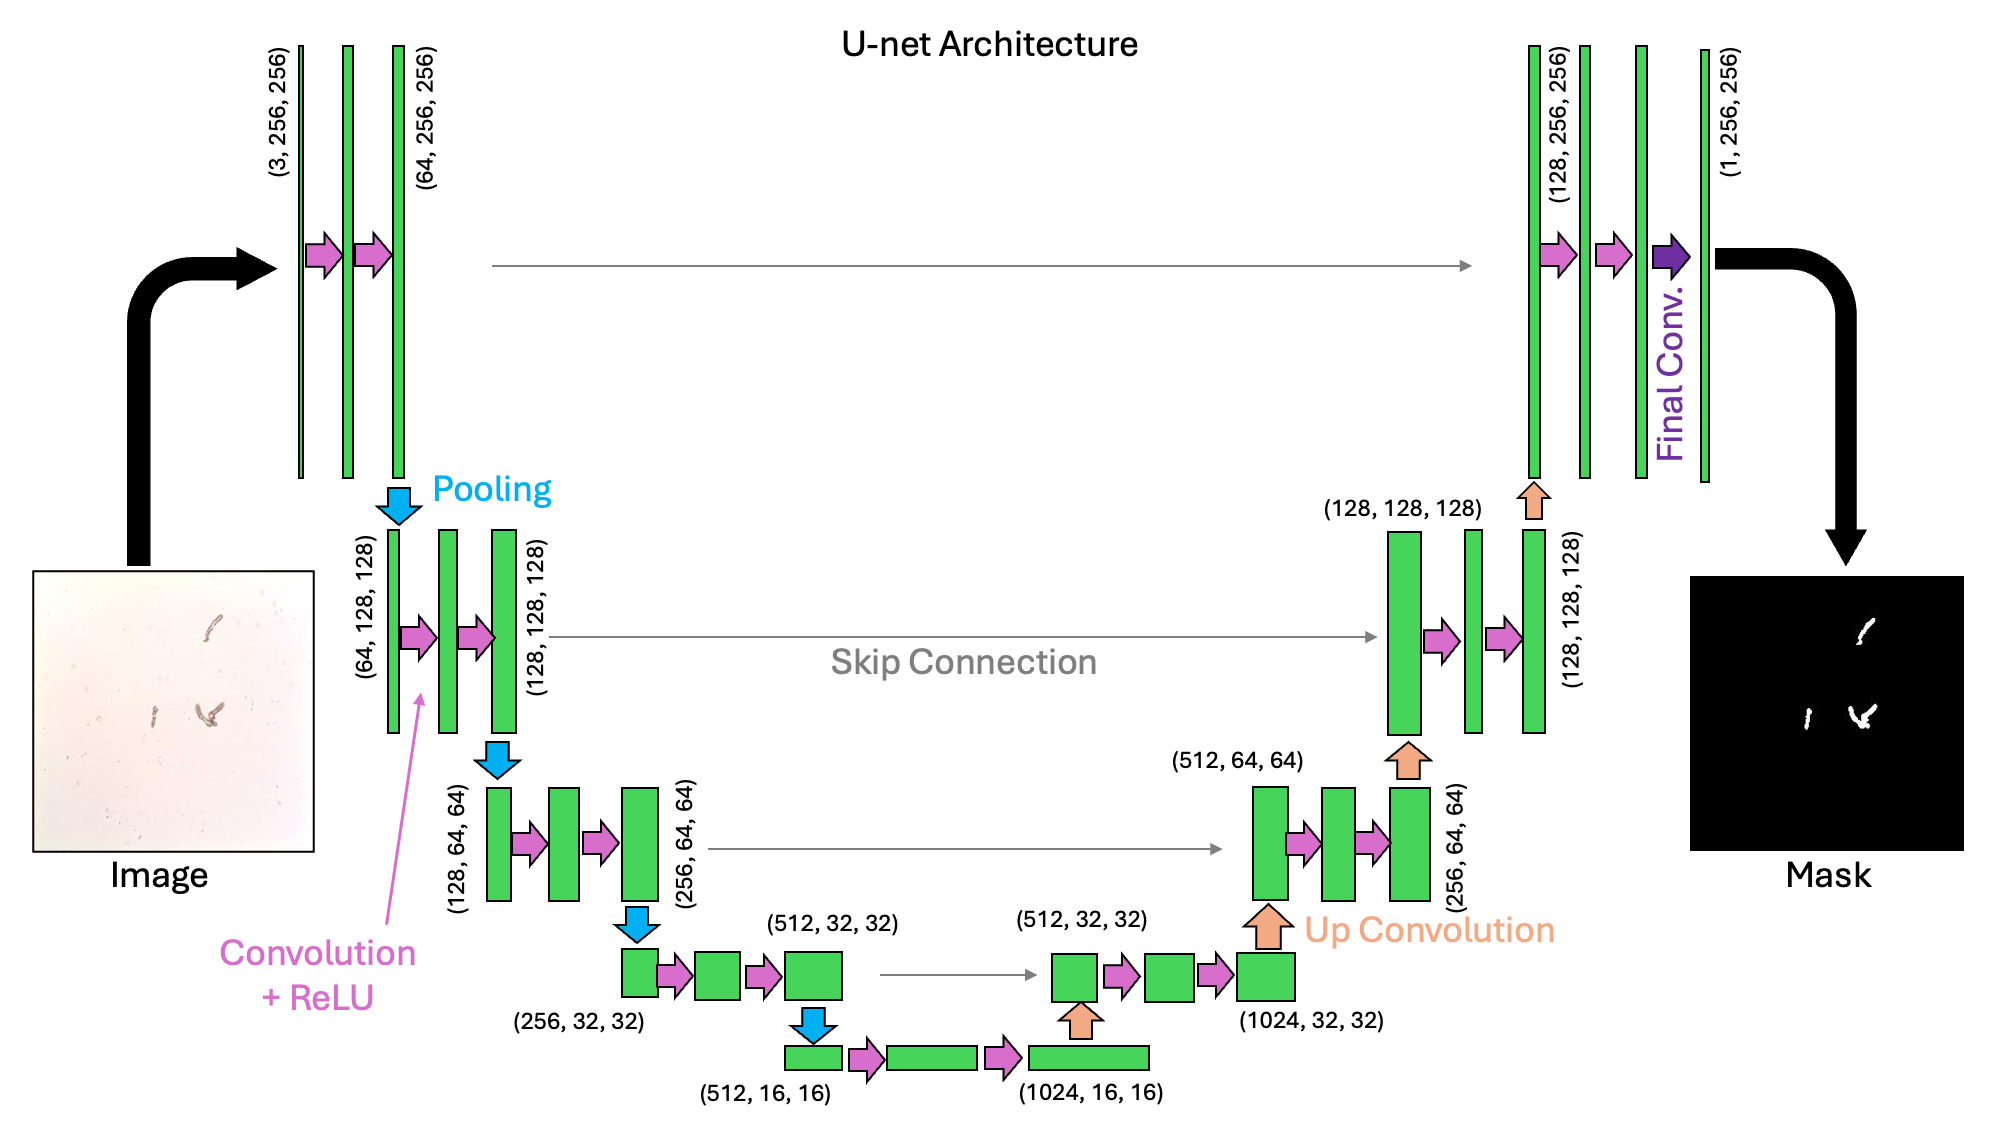

In [7]:
display(IPI(filename=os.path.join(images_dir, 'Unet_schematic.png'), width=800))

We can see from the schematic above why this architecture would be called a "U-net". It is a collection of convolutions that extract image features at a variety of scales.

Let's start to code this up here. To start, let's make a helper function called `double_conv` which will apply two sequential convolutional, batch normalization, and `ReLU` (non-linear) layers:

In [8]:
def double_conv(in_ch, out_ch, dilation=1):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=dilation,
                  dilation=dilation, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=dilation,
                  dilation=dilation, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    )

Next, let's construct a `Unet` class from the `nn.Module` class, following the structure in the image above.

In [9]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512], dilation=1):
        super().__init__()
        
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Formulate the encoder
        self.downs = nn.ModuleList()
        ch_in = in_channels
        for feat in features:
            self.downs.append(double_conv(ch_in, feat))
            ch_in = feat

        # The "bottleneck" also has a double convolutional layer
        self.bottleneck = double_conv(features[-1], features[-1] * 2, dilation=dilation)

        # Formulate the decoder 
        ch_in = features[-1] * 2
        for feat in reversed(features):
            self.ups.append(nn.ConvTranspose2d(ch_in, feat, kernel_size=2, stride=2))
            self.ups.append(double_conv(ch_in, feat))
            ch_in = feat

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):

        # make a list for the skip connections
        skip_connections = []

        # make the downward U section
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        # make the bottleneck
        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        # make the upward U section
        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)  # upsample
            skip = skip_connections[idx // 2]
            x = torch.cat([skip, x], dim=1)
            x = self.ups[idx + 1](x)

        return self.final_conv(x)

In the code block above, we define an `init` function and a `forward` function in the same way we've done for the other PyTorch models we've created so far.

## Setting up the Training Loop

In order to train our model, we're going to need `DataLoader` objects for the training and the testing sets. We'll do this by designing a `GametophyteDataset` class that extends the `Dataset` class from PyTorch: 

In [10]:
class GametophyteDataset(Dataset):
    def __init__(self, images_dir, masks_dir, img_transform = None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.img_transform = img_transform

        # make a list of source files
        self.img_files = []
        self.msk_files = []
        for file_name in sorted(os.listdir(images_dir)):
            if file_name[0]!='.' and file_name.endswith('.jpeg'):
                if file_name[:-5]+'_mask.jpg' in os.listdir(masks_dir):
                    self.img_files.append(file_name)
                    self.msk_files.append(file_name[:-5]+'_mask.jpg')

    # overwrite the len function
    def __len__(self):
        return len(self.img_files)

    # overwrite the getitem function
    def __getitem__(self, idx):
        img_path = os.path.join(self.images_dir, self.img_files[idx])
        msk_path = os.path.join(self.masks_dir, self.msk_files[idx])

        # load the image and the corresponding mask
        img = Image.open(img_path).convert("RGB") # shape: (H, W, 3)
        mask = Image.open(msk_path).convert("L")  # shape: (H, W, 1)

        # convert the image ang mask to a tensor
        img = TF.to_tensor(img)  # shape: (3,H,W)
        mask = TF.to_tensor(mask)  # shape: (1,H,W)

        # convert the mask to 1's and 0's
        mask = (mask > 0).float()

        # Apply image transforms if they were provided
        if self.img_transform is not None:
            img = self.img_transform(img)

        return img, mask

Using this class, we can create our datasets and loader objects as follows:

In [11]:
# define the locations of the images and the corresponding masks
images_dir = os.path.join(data_dir, "Images")
masks_dir = os.path.join(data_dir, "Masks")

# determine a batch size for loading
batch_size=4

# determine how many images will be used in training vs testing
test_split=0.2

# create a transform
img_tf = transforms.Compose([transforms.Normalize(mean=[0.5, 0.05, 0.5],
                                std=[0.25, 0.25, 0.25])])

# make the dataset of images
ds = GametophyteDataset(images_dir, masks_dir, img_transform=img_tf)

# split the data into training and testing sets
n_test = int(len(ds) * test_split)
n_train = len(ds) - n_test
train_ds, test_ds = random_split(ds, [n_train, n_test])

# create the DataLoaders
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

With our data loader in hand, next we'll consider the loss function. Here, we'll use the binary cross entropy loss that's designed to be applied to "logits" (as defined in our previous notebook on Logistic Regression). We saw the cross entropy loss in the previous notebook on CNNs - this one takes a similar form as follows:

$$
L(x,y)=\text{max}(x,0)−x⋅y+\log(1+\exp(-|x|))
$$

The difference in this function compared to the previous function is that a sigmoid function has been applied to the values of the logit before it is passed into the loss (and a little bit of rearranging has been done). 

In PyTorch, we'll implement this with the following function:

In [12]:
criterion = nn.BCEWithLogitsLoss()  # for binary masks

Up next, we'll write two functions - one for the training loop, and one for the testing loop.

First, let's define the training step:

In [13]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        loss = criterion(logits, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    return running_loss / len(loader.dataset)

Then for the testing epoch:

In [14]:
@torch.no_grad()
def test_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    n_samples = 0
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        loss = criterion(logits, masks)
        running_loss += loss.item() * imgs.size(0)
        n_samples += imgs.size(0)
    return running_loss / n_samples

As we can see above, we added a little fanciness to our testing function - the `@torch.no_grad()` decorator. When used on a function, this is the same thing as running the code with the `with @torch.no_grad()` lines that we used in previous examples.

## Training the Model

With the above tools in hand, we're ready to start training the model. 

Let's define our model and our `Adam` optimizer here:

In [15]:
model = UNet(in_channels=3, out_channels=1).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

Next, let's define our training loop iteration. Since we're going to run this several times below, let's bundle this into a function:

In [16]:
def train(model, criterion, epochs, train_loader, test_loader, device, printing=True):

    train_losses = []
    test_losses = []
    
    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        train_losses.append(train_loss)
        
        test_loss = test_epoch(model, test_loader, criterion, device)
        test_losses.append(test_loss)

        if printing:
            print(f"[{epoch:02d}/{epochs}] "
                  f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")
            
    return(train_losses, test_losses)

Ok! Time for training:

In [17]:
# define a number of epochs
epochs=30

# run the training
train_losses, test_losses = train(model, criterion, epochs, train_loader, test_loader, device)

[01/30] Train Loss: 0.4223 | Test Loss: 0.8270
[02/30] Train Loss: 0.2628 | Test Loss: 1.5614
[03/30] Train Loss: 0.2161 | Test Loss: 4.1917
[04/30] Train Loss: 0.1818 | Test Loss: 0.1768
[05/30] Train Loss: 0.1537 | Test Loss: 0.1430
[06/30] Train Loss: 0.1314 | Test Loss: 0.1191
[07/30] Train Loss: 0.1148 | Test Loss: 0.1087
[08/30] Train Loss: 0.1006 | Test Loss: 0.0950
[09/30] Train Loss: 0.0889 | Test Loss: 0.0777
[10/30] Train Loss: 0.0800 | Test Loss: 0.0815
[11/30] Train Loss: 0.0717 | Test Loss: 0.0746
[12/30] Train Loss: 0.0671 | Test Loss: 0.0604
[13/30] Train Loss: 0.0606 | Test Loss: 0.0539
[14/30] Train Loss: 0.0562 | Test Loss: 0.0500
[15/30] Train Loss: 0.0543 | Test Loss: 0.0635
[16/30] Train Loss: 0.0513 | Test Loss: 0.0446
[17/30] Train Loss: 0.0479 | Test Loss: 0.0379
[18/30] Train Loss: 0.0451 | Test Loss: 0.0374
[19/30] Train Loss: 0.0425 | Test Loss: 0.0421
[20/30] Train Loss: 0.0405 | Test Loss: 0.0395
[21/30] Train Loss: 0.0389 | Test Loss: 0.0359
[22/30] Train

Let's have a look at how our model is performing. As usual, we'll first have a look at our training and testing losses. Let's put this into a function as well so we can reuse it:

In [18]:
def plot_losses(train_losses,test_losses):
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, 'd-', label='Training Loss')
    plt.plot(test_losses, 'd-', label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Testing Loss Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

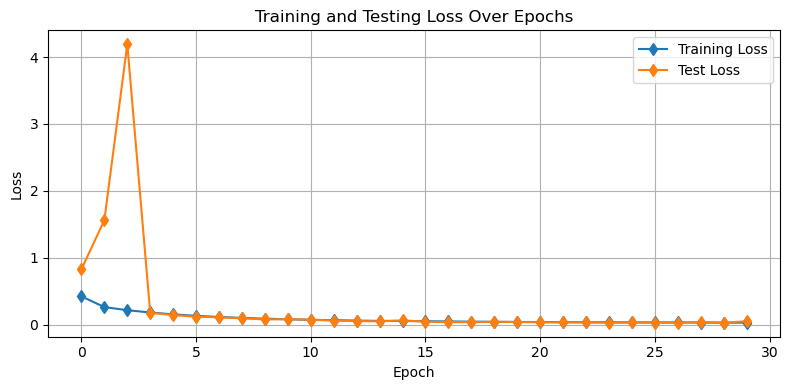

In [19]:
plot_losses(train_losses,test_losses)

We can also look visually at our demo examples to see how the model is doing. As above, let's put this into a function:

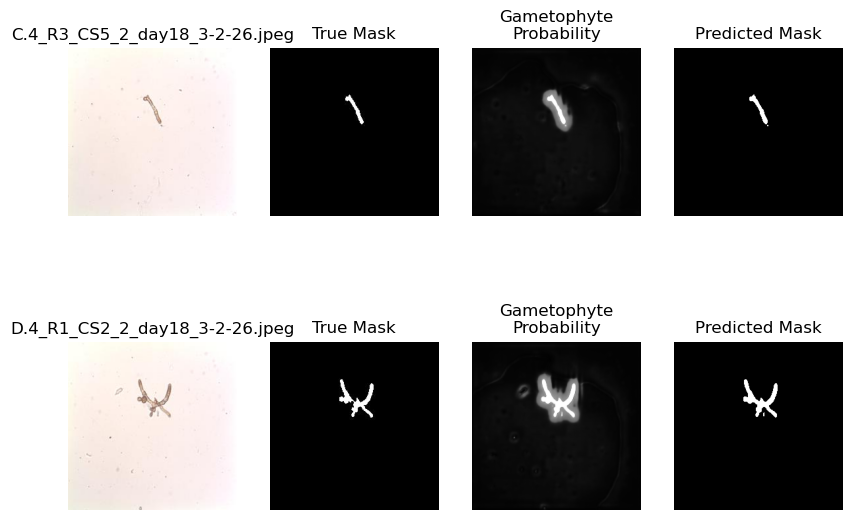

In [20]:
def plot_demo_image(model):

    # put the model in eval mode
    model.eval()
    
    # get the paths of the example images
    img_names = ['C.4_R3_CS5_2_day18_3-2-26.jpeg', 'D.4_R1_CS2_2_day18_3-2-26.jpeg']
    
    fig = plt.figure(figsize=(10,7))
    
    for i, img_name in enumerate(img_names):
    
        img_path = os.path.join(data_dir, 'Images', img_name)
        msk_path = os.path.join(data_dir, 'Masks', img_name[:-5]+'_mask.jpg')
    
        img = Image.open(img_path).convert("RGB")
        true_msk = Image.open(msk_path).convert("L")

        # Convert to tensor
        img_tensor = TF.to_tensor(img) 
        img_tensor = img_tf(img_tensor).unsqueeze(0).to(device)

        # Compute the "probability" that the pixels are gametophytes
        with torch.no_grad():
            logits = model(img_tensor)
            logits = logits.cpu().numpy().squeeze()
            prob = 1/(1+np.exp(-logits))
            pred_mask = prob>0.6
    
        plt.subplot(2,4,4*i+1)
        plt.imshow(img)
        plt.title(img_name)
        plt.axis('off')
    
        plt.subplot(2,4,4*i+2)
        plt.imshow(true_msk,vmin=0,vmax=255, cmap='Grays_r')
        plt.title('True Mask')
        plt.axis('off')
        
        plt.subplot(2,4,4*i+3)
        plt.imshow(prob,vmin=0,vmax=1, cmap='Grays_r')
        plt.title('Gametophyte\nProbability')
        plt.axis('off')

        plt.subplot(2,4,4*i+4)
        plt.imshow(pred_mask,vmin=0,vmax=1, cmap='Grays_r')
        plt.title('Predicted Mask')
        plt.axis('off')
    plt.show()

plot_demo_image(model)

Looking at the plot above, we can see that the model is doing a pretty good job. It's picking out the right features that pertain to the gametophytes. Let's see how we might modify this architecture to see some alternative approaches.

## Modifying the U-net architecture

There are a few things we can do to modify the `Unet` architecture including:
- modify the number of "levels" and their sizes
- implement a "dilation" in the bottleneck layer

Let's try these one-by-one to observe their influence on the model:

### Reducing the number of feature layers

In the example above, we used four layers of size `features=[64, 128, 256, 512]`. Let's remove one and reduce their sizes to see how the layers affect the output:

In [21]:
model = UNet(in_channels=3, out_channels=1, features=[32, 64, 128]).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

In [22]:
# run the training
train_losses, test_losses =\
    train(model, criterion, epochs, train_loader, test_loader, device)

[01/30] Train Loss: 0.5695 | Test Loss: 0.5390
[02/30] Train Loss: 0.4258 | Test Loss: 0.4787
[03/30] Train Loss: 0.3711 | Test Loss: 0.4079
[04/30] Train Loss: 0.3304 | Test Loss: 0.3350
[05/30] Train Loss: 0.2950 | Test Loss: 0.2734
[06/30] Train Loss: 0.2668 | Test Loss: 0.2407
[07/30] Train Loss: 0.2419 | Test Loss: 0.2178
[08/30] Train Loss: 0.2192 | Test Loss: 0.2011
[09/30] Train Loss: 0.1996 | Test Loss: 0.1885
[10/30] Train Loss: 0.1837 | Test Loss: 0.1676
[11/30] Train Loss: 0.1674 | Test Loss: 0.1545
[12/30] Train Loss: 0.1538 | Test Loss: 0.1386
[13/30] Train Loss: 0.1413 | Test Loss: 0.1287
[14/30] Train Loss: 0.1299 | Test Loss: 0.1180
[15/30] Train Loss: 0.1203 | Test Loss: 0.1105
[16/30] Train Loss: 0.1117 | Test Loss: 0.1019
[17/30] Train Loss: 0.1031 | Test Loss: 0.0929
[18/30] Train Loss: 0.0958 | Test Loss: 0.0867
[19/30] Train Loss: 0.0898 | Test Loss: 0.0824
[20/30] Train Loss: 0.0843 | Test Loss: 0.0751
[21/30] Train Loss: 0.0787 | Test Loss: 0.0745
[22/30] Train

Let's check out how the losses look:

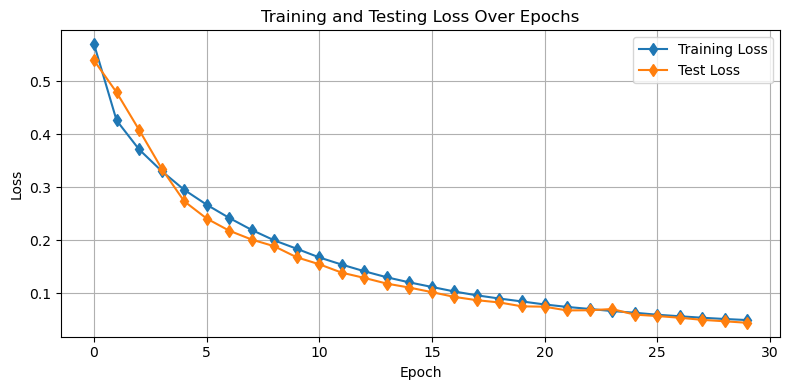

In [23]:
plot_losses(train_losses,test_losses)

Further, let's see how we're doing on our demo images

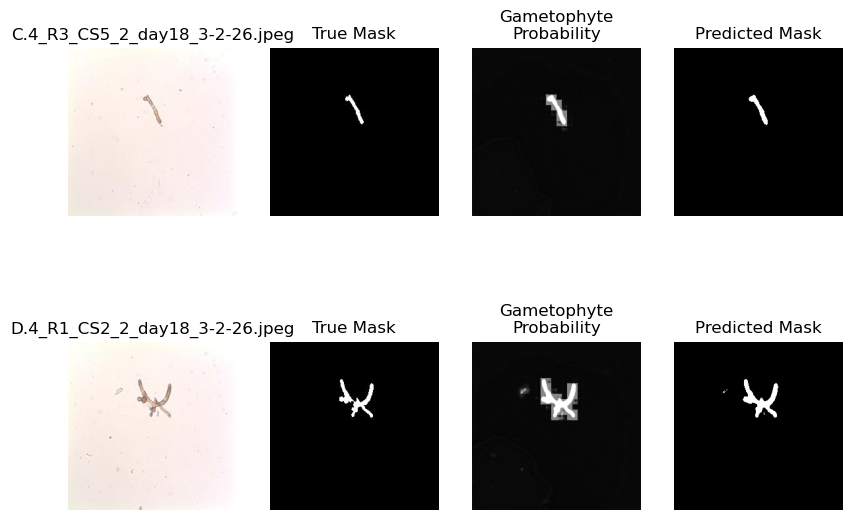

In [24]:
plot_demo_image(model)

Above, we can see that the lower amount of features results in a more "blurry" result compared to the previous model. This is because the smaller scale features in the image are learned and passed on by larger kernels. Let's check out another option.

### Adding Dilation to the Bottleneck

The bottleneck of the U-net architecture is the section between the encoder and the decoder. A dilation adds spaces within the convolutional kernel so that it can learn a broader range of features. We have already built in dilation to this model so let's implement it here.

In [25]:
model = UNet(in_channels=3, out_channels=1, dilation=2).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

In [26]:
# run the training
train_losses, test_losses =\
    train(model, criterion, epochs, train_loader, test_loader, device)

[01/30] Train Loss: 0.3729 | Test Loss: 5.5492
[02/30] Train Loss: 0.2268 | Test Loss: 2.3052
[03/30] Train Loss: 0.1808 | Test Loss: 0.2130
[04/30] Train Loss: 0.1495 | Test Loss: 0.1384
[05/30] Train Loss: 0.1277 | Test Loss: 0.1036
[06/30] Train Loss: 0.1073 | Test Loss: 0.0940
[07/30] Train Loss: 0.0911 | Test Loss: 0.0826
[08/30] Train Loss: 0.0805 | Test Loss: 0.0685
[09/30] Train Loss: 0.0721 | Test Loss: 0.0606
[10/30] Train Loss: 0.0645 | Test Loss: 0.0544
[11/30] Train Loss: 0.0586 | Test Loss: 0.0492
[12/30] Train Loss: 0.0533 | Test Loss: 0.0468
[13/30] Train Loss: 0.0496 | Test Loss: 0.0439
[14/30] Train Loss: 0.0464 | Test Loss: 0.0435
[15/30] Train Loss: 0.0429 | Test Loss: 0.0408
[16/30] Train Loss: 0.0404 | Test Loss: 0.0370
[17/30] Train Loss: 0.0377 | Test Loss: 0.0319
[18/30] Train Loss: 0.0354 | Test Loss: 0.0320
[19/30] Train Loss: 0.0355 | Test Loss: 0.0266
[20/30] Train Loss: 0.0350 | Test Loss: 0.0358
[21/30] Train Loss: 0.0335 | Test Loss: 0.0487
[22/30] Train

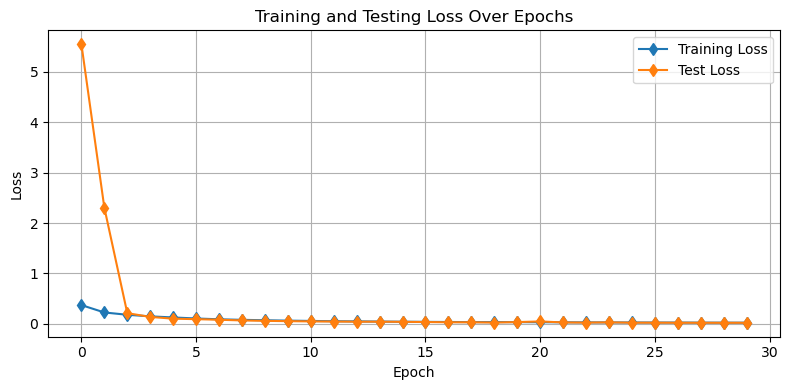

In [27]:
plot_losses(train_losses,test_losses)

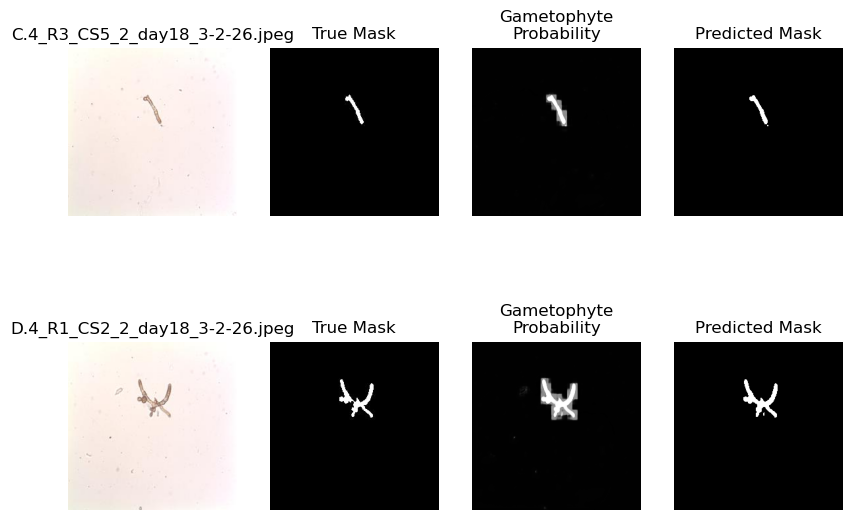

In [28]:
plot_demo_image(model)

## Using the Model for Analysis

One motivation for generating this model was to analyze the area of gametophytes under different treatments. Here, we will compare the areas of gametophytes between two divisions of the experiment - "C" and "D" corresponding to gametophytes that have been exposed to 12 and 24 hours of blue light per day. To assess these differences, first we will need a way to compute the area of gametophyte(s) in a given mask. Using the information that each image is sized 0.52 mm x 0.52 mm (520 $\mu$m x 520 $\mu$m), we can code this up into the following function:

In [29]:
def compute_area_from_mask(mask):
    pixel_area = 520.0/np.shape(mask)[0]*520.0/np.shape(mask)[1] # um^2
    area = np.sum(mask)*pixel_area
    return(area)

Let's have a look at one example:

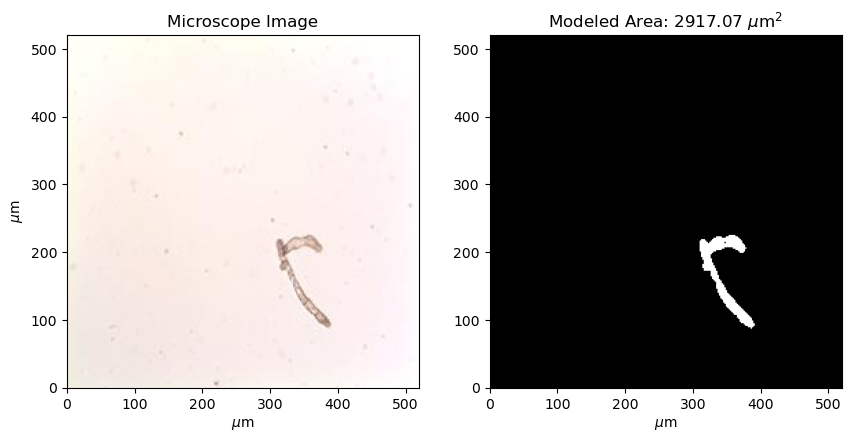

In [30]:
img_path = os.path.join(data_dir, 'Images', 'C.8_R5_CS7_2_day18_3-2-26.jpeg')
img = Image.open(img_path)

# use the model to compute the mask
img_tensor = TF.to_tensor(img) 
img_tensor = img_tf(img_tensor).unsqueeze(0).to(device)
with torch.no_grad():
    logits = model(img_tensor)
    logits = logits.cpu().numpy().squeeze()
    prob = 1/(1+np.exp(-logits))
    mask = prob>0.6

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img,extent=[0,520,0,520])
plt.xlabel('$\\mu$m')
plt.ylabel('$\\mu$m')
plt.title('Microscope Image')
plt.subplot(1,2,2)
plt.imshow(mask,extent=[0,520,0,520], cmap='Grays_r')
plt.title('Modeled Area: '+'{:.2f}'.format(compute_area_from_mask(mask))+' $\\mu$m$^2$')
plt.xlabel('$\\mu$m')
plt.show()

With our area function in hand, let's estimate the areas for all images at day 18 in the experiment:

In [31]:
# make some list to hold the areas
C_areas = []
D_areas = []

# loop through all of the images on day 18
for img_name in os.listdir(os.path.join(data_dir,'Images')):
    if img_name[0]!='.' and img_name.endswith('.jpeg') and 'day18' in img_name:
        img_path = os.path.join(data_dir,'Images', img_name)
    
        img = Image.open(img_path).convert("RGB")
        img_tensor = TF.to_tensor(img) 
        img_tensor = img_tf(img_tensor).unsqueeze(0).to(device)

        # use the model to compute the mask and then estimate the area
        with torch.no_grad():
            logits = model(img_tensor)
            logits = logits.cpu().numpy().squeeze()
            prob = 1/(1+np.exp(-logits))
            pred_mask = prob>0.6
            area = compute_area_from_mask(pred_mask)
            if img_name[0]=='C':
                C_areas.append(area)
            if img_name[0]=='D':
                D_areas.append(area)

Let's take a look at the results:

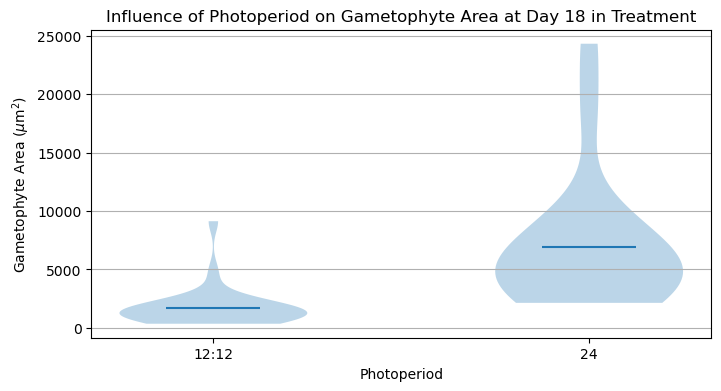

In [32]:
plt.figure(figsize=(8,4))
plt.violinplot([C_areas, D_areas], showmeans=True, showextrema=False)
plt.gca().yaxis.grid(True)
plt.gca().set_xticks([1,2], labels=['12:12','24'])
plt.gca().set_xlabel('Photoperiod')
plt.gca().set_ylabel('Gametophyte Area ($\\mu$m$^2$)')
plt.title('Influence of Photoperiod on Gametophyte Area at Day 18 in Treatment')
plt.show()

It looks like there is a significant difference between these two treatments! An appropriate statistical test would help make this conclusion more robust.

**Key Takeaways**

1. A U-net is a type of convolutional neural network architecture that has both encoding (or "down-sampling") and decoding (or "up-sampling") convolutional layers.
2. A U-net is designed to return the values of a matrix (i.e. an image) given those in another matrix (i.e. an image or set of images).
3. The different components of the U-net architecture directly map onto the final output product.